In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
df = pd.read_csv(
    "/content/Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

In [4]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df['Text'].values[0]

'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [7]:
df.shape

(568454, 10)

In [12]:
df = df.head(500)

In [13]:
print(df.shape)

(500, 10)


In [14]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### **Counts of score for the first 800 sample size from the dataset**

In [15]:
df['Score'].value_counts().sort_index()

,count
Score,
1,36
2,18
3,37
4,70
5,339


### **Importing libraries for data preprocessing**

In [16]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

In [17]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### **Defining texts into pos, neu and neg**

In [18]:
def get_sentiment(score):
    if score <= 2:
        return 'neg'
    elif score == 3:
        return 'neu'
    else:
        return 'pos'

df["Sentiment"] = df["Score"].apply(get_sentiment)

### **Number of Sentiment review, whether customer review is positive , neutral or negative statement**

In [19]:
df["Sentiment"].value_counts()

,count
Sentiment,
pos,409
neg,54
neu,37


### **Text Preprocessing**

In [20]:
Lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

### **Removing stop words and unwanted characters**

In [21]:


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    text = str(text).lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

### **Creating a sample data**

In [22]:
sample_df = df.sample(500, random_state=42)

### **Applying the preprocessed text to the sample data**

In [23]:
sample_df["clean_Text"] = (sample_df["Text"].apply(preprocess_text))

### **Counts of sentiment reviews on the sample data**

In [24]:
sentiment_counts = sample_df["Sentiment"].value_counts()
sentiment_counts

,count
Sentiment,
pos,409
neg,54
neu,37


### **Visualization of the sentiments counts on the 500 sample size**

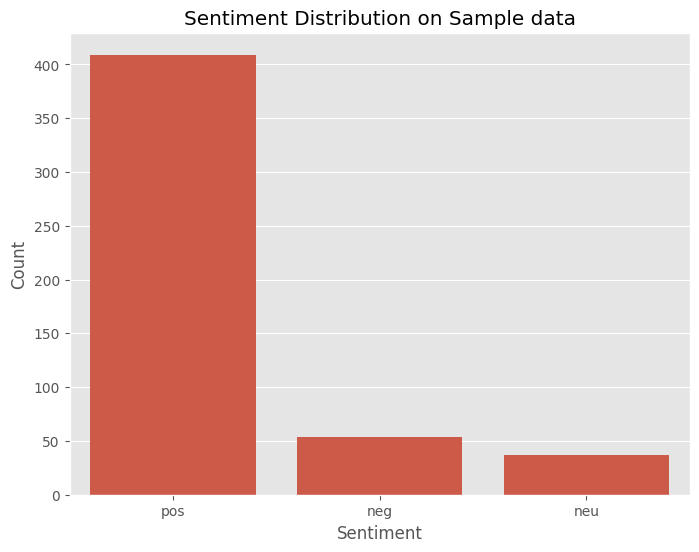

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution on Sample data")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### **Defining a variable for the most frequent words by customers**

In [27]:
all_words = ' '.join([text for text in sample_df['clean_Text']])

In [28]:
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='black').generate(all_words)

### **Visualization of Most frequent words**

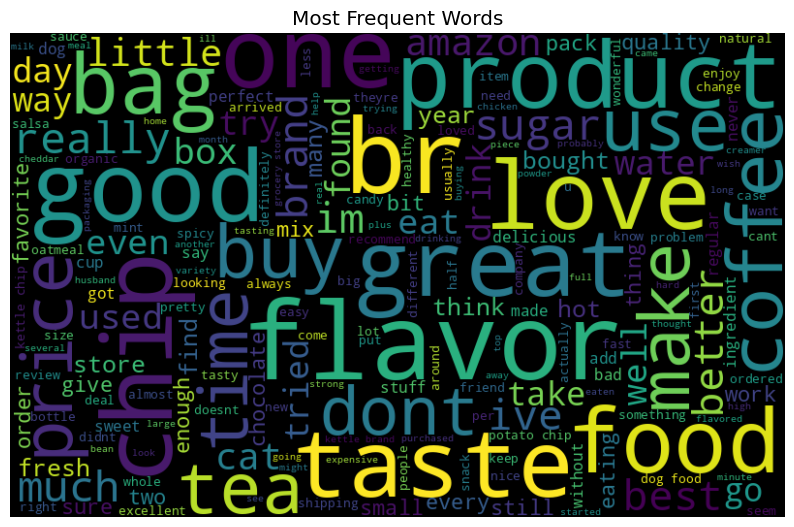

In [29]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Frequent Words')
plt.axis('off')
plt.show()

### **Most frequently used words on positive reviews**

In [30]:
positive_text = " ".join(text for text in sample_df[sample_df['Sentiment'] == 'pos']['clean_Text'])

In [31]:
positive_text_cloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='black').generate(positive_text)

### **Visualization on most used words on Positive reviews from customers**

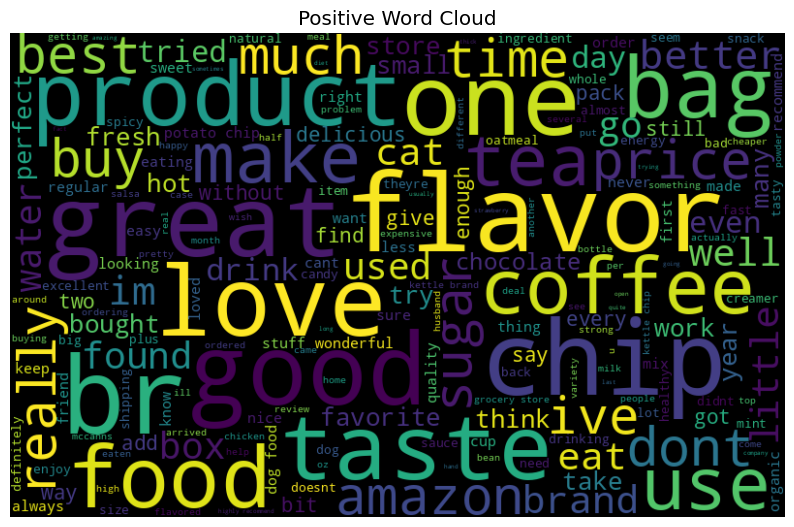

In [32]:
plt.figure(figsize=(10, 7))
plt.imshow(positive_text_cloud, interpolation='bilinear')
plt.title('Positive Word Cloud')
plt.axis('off')
plt.show()

### **Most frequently used words on Negative reviews**

In [33]:
negative_text = " ".join(text for text in sample_df[sample_df['Sentiment'] == 'neg']['clean_Text'])

In [34]:
negative_text_cloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='black').generate(negative_text)

### **Visualization on most used words on Negative reviews from customers **

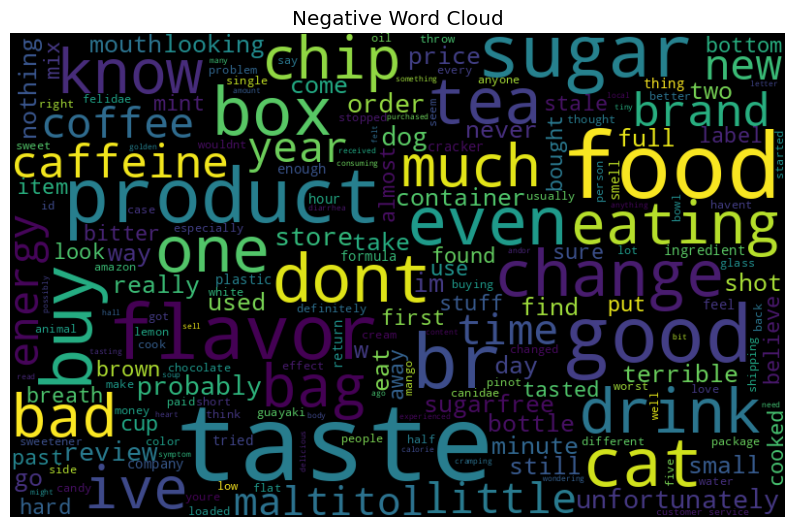

In [35]:
plt.figure(figsize=(10, 7))
plt.imshow(negative_text_cloud, interpolation='bilinear')
plt.title('Negative Word Cloud')
plt.axis('off')
plt.show()

### **Most frequently used words on Neutral reviews**

In [36]:
neutral_text = " ".join(text for text in sample_df[sample_df['Sentiment'] == 'neu']['clean_Text'])

In [37]:
neutral_text_cloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='black').generate(neutral_text)

### **Visualization on the most used words on Neutral reviews from customers**

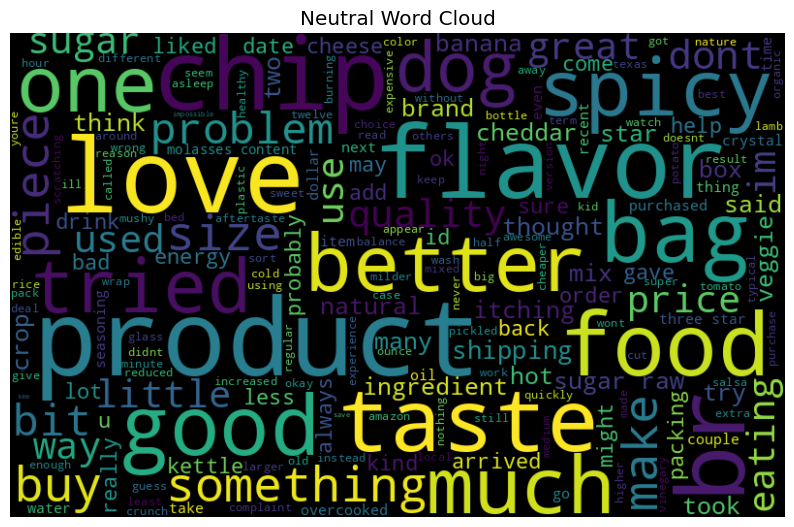

In [38]:
plt.figure(figsize=(10, 7))
plt.imshow(neutral_text_cloud, interpolation='bilinear')
plt.title('Neutral Word Cloud')
plt.axis('off')
plt.show()

### **Using Vader(Valence Aware Dictionary sEntiment Reasoner) to analyze the sentiments of each customer**

In [39]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [49]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [50]:
sia = SentimentIntensityAnalyzer()

In [42]:
def get_compound_score(text):
    score = sia.polarity_scores(text)
    return score['compound']

In [51]:
sample_df["compound_score"] = (sample_df["Text"].apply(get_compound_score))

In [52]:
def vader_sentiment(text):

    compound = sia.polarity_scores(str(text))["compound"]

    if compound >= 0.05:
        return "pos"

    elif compound <= -0.05:
        return "neg"

    else:
        return "neu"

In [53]:
sample_df["Predicted_Sentiment"] = (sample_df["Text"].apply(vader_sentiment))

In [54]:
sample_df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'Sentiment', 'clean_Text', 'compound_score', 'Predicted_Sentiment'],
      dtype='object')

In [56]:
sample_df[
    [
        "Score",
        "Sentiment",
        "Predicted_Sentiment",
        "compound_score"
    ]
].head()

,Score,Sentiment,Predicted_Sentiment,compound_score
361,1,neg,neg,-0.7340
73,1,neg,pos,0.9665
374,5,pos,pos,0.9472
155,5,pos,pos,0.9681
104,5,pos,pos,0.9313


In [58]:
sample_df.sort_index(inplace=True)

In [59]:
sample_df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,clean_Text,compound_score,Predicted_Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,pos,bought several vitality canned dog food produc...,0.9441,pos
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,neg,product arrived labeled jumbo salted peanutsth...,-0.5664,neg
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,pos,confection around century light pillowy citrus...,0.8265,pos
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,neg,looking secret ingredient robitussin believe f...,0.0000,neu
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,pos,great taffy great price wide assortment yummy ...,0.9468,pos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,B000G6RYNE,APGAA43E3WPN7,Darren,0,0,5,1201392000,amazing chips,i rarely eat chips but i saw these and tried t...,pos,rarely eat chip saw tried really amazing love ...,0.9725,pos
496,497,B000G6RYNE,ABR7HU5H1KNE,Keith,0,0,5,1196726400,Best Chip Ever,This is easily the best potato chip that I hav...,pos,easily best potato chip ever look ingredient g...,0.7833,pos
497,498,B000G6RYNE,AJQD2WWJYOYFQ,bubbles,0,0,4,1186617600,"Tangy, spicy, and sweet- oh my!",Kettle Chips Spicy Thai potato chips have the ...,pos,kettle chip spicy thai potato chip perfect amo...,0.9848,pos
498,499,B000G6RYNE,A16YH487W9ZYO0,Bruce G. Lindsay,0,0,4,1184198400,An indulgence with a bite,"Okay, I should not eat potato chips, nor shoul...",pos,okay eat potato chip anyonebr spicy would find...,0.1280,pos
